In [1]:
from detecto import core, utils
from detecto.visualize import show_labeled_image
from torchvision import transforms
import numpy as np

In [2]:
path_images = 'datasets/object_detection/images'
path_train_labels = 'datasets/object_detection/train_labels'
path_test_labels = 'datasets/object_detection/test_labels'

In [3]:
custom_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((50)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    utils.normalize_transform()
])

In [4]:
trained_labels = ['apple', 'banana']

train_dataset = core.Dataset(image_folder=path_images, label_data=path_train_labels, transform=custom_transforms)
test_dataset = core.Dataset(image_folder=path_images, label_data=path_test_labels, transform=custom_transforms)

train_loader = core.DataLoader(train_dataset, batch_size=2, shuffle=False)
test_loader = core.DataLoader(test_dataset, batch_size=2, shuffle=False)

In [5]:
train_dataset[0][0]

C:\Users\praveenchakra.bh\AppData\Roaming\Python\Python39\site-packages\detecto\core.py:166: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boxes = torch.tensor(boxes).view(-1, 4)


tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [6]:
model = core.Model(trained_labels)

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
model.get_internal_model()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
losses = model.fit(train_loader, test_dataset, epochs=20, verbose=True)

Epoch 1 of 20
Begin iterating over training dataset


100%|██████████████████████| 66/66 [03:09<00:00,  2.88s/it]


Begin iterating over validation dataset


100%|██████████████████████| 34/34 [00:04<00:00,  6.99it/s]


Loss: 0.517387186341426
Epoch 2 of 20
Begin iterating over training dataset


...

Begin iterating over validation dataset


100%|██████████████████████| 34/34 [00:05<00:00,  6.33it/s]


Loss: 0.21419884669868386
Epoch 9 of 20
Begin iterating over training dataset


 18%|████                  | 12/66 [00:16<01:12,  1.34s/it]


KeyboardInterrupt: 

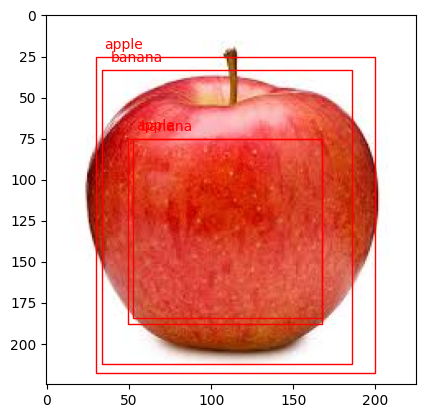

In [9]:
test_image_path = 'test/apple.jpg'
test_image = utils.read_image(test_image_path)
pred = model.predict(test_image)
labels, boxes, scores = pred
show_labeled_image(test_image, boxes, labels)

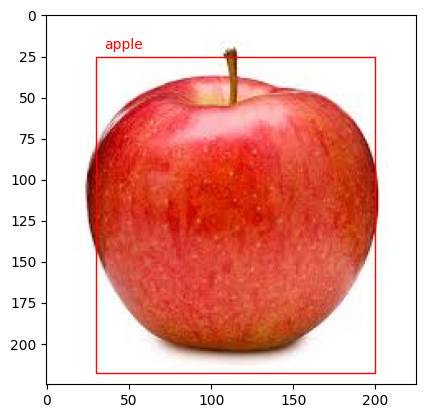

In [10]:
conf_threshold = 0.7
filtered_indices = np.where(scores > conf_threshold)
filteres_scores = scores[filtered_indices]
filtered_boxes = boxes[filtered_indices]
num_list = filtered_indices[0].tolist()
filtered_labels = [labels[i] for i in num_list]
show_labeled_image(test_image, filtered_boxes, filtered_labels)

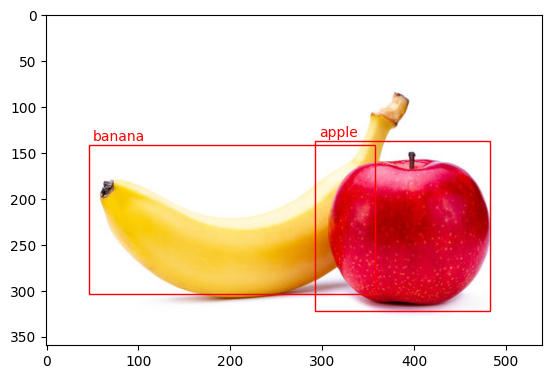

In [14]:
test_image_path = 'test/apples.jpg'
test_image = utils.read_image(test_image_path)
pred = model.predict(test_image)
labels, boxes, scores = pred
conf_threshold = 0.79
filtered_indices = np.where(scores > conf_threshold)
filteres_scores = scores[filtered_indices]
filtered_boxes = boxes[filtered_indices]
num_list = filtered_indices[0].tolist()
filtered_labels = [labels[i] for i in num_list]
show_labeled_image(test_image, filtered_boxes, filtered_labels)